In [1]:
import pandas as pd


In [9]:

pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")

# --- Pokemon file ---
print("POKEMON shape:", pokemon.shape)
print(pokemon.head())
print("\n--- Pokemon info ---")
pokemon.info()
print("\n--- Missing values in pokemon ---")
print(pokemon.isnull().sum())

# --- Combats file ---
print("\n" + "="*50)
print("COMBATS shape:", combats.shape)
print(combats.head())
print("\n--- Combats info ---")
combats.info()
print("\n--- Missing values in combats ---")
print(combats.isnull().sum())

POKEMON shape: (800, 12)
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
2  3       Venusaur  Grass  Poison  80      82       83      100      100   
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
4  5     Charmander   Fire     NaN  39      52       43       60       50   

   Speed  Generation  Legendary  
0     45           1      False  
1     60           1      False  
2     80           1      False  
3     80           1      False  
4     65           1      False  

--- Pokemon info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 

In [10]:
# STEP 1b: Fix missing values (FINAL)

# --- Fix 1: Fill the missing Name (Primeape) ---
pokemon.loc[pokemon['Name'].isnull(), 'Name'] = 'Primeape'

# --- Fix 2: Type 2 NaN -> "None" (single-type Pokemon) ---
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

# --- Verify ---
print("Missing values after fixes:")
print(pokemon.isnull().sum())
print("\nTotal missing:", pokemon.isnull().sum().sum())

Missing values after fixes:
#             0
Name          0
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

Total missing: 0


In [11]:
# STEP 1c: Calculate win percentage

# --- Count total battles each Pokemon participated in ---
# A Pokemon can appear as First_pokemon OR Second_pokemon
first_counts  = combats['First_pokemon'].value_counts()
second_counts = combats['Second_pokemon'].value_counts()
total_battles = first_counts.add(second_counts, fill_value=0)

# --- Count wins (Winner column holds the # of the winning Pokemon) ---
win_counts = combats['Winner'].value_counts()

# --- Build a summary DataFrame ---
stats = pd.DataFrame({
    'total_battles': total_battles,
    'wins': win_counts
}).fillna(0)   # a Pokemon with 0 wins won't appear in win_counts -> NaN -> 0

stats['win_pct'] = (stats['wins'] / stats['total_battles']) * 100

print("Pokemon appearing in combats:", len(stats))
print("\nSample of stats:")
print(stats.head())

# --- Check: any Pokemon that never battled? ---
print("\nPokemon in pokemon.csv:", len(pokemon))
print("Pokemon that fought at least one battle:", len(stats))

Pokemon appearing in combats: 784

Sample of stats:
   total_battles  wins    win_pct
1            133  37.0  27.819549
2            121  46.0  38.016529
3            132  89.0  67.424242
4            125  70.0  56.000000
5            112  55.0  49.107143

Pokemon in pokemon.csv: 800
Pokemon that fought at least one battle: 784


In [12]:
# STEP 1d: Merge stats onto pokemon table

# stats is indexed by Pokemon '#'. Bring '#' back as a column for merging.
stats = stats.reset_index().rename(columns={'index': '#'})
print("stats columns:", stats.columns.tolist())

# --- Merge (left join keeps all 800; non-fighters get NaN win_pct) ---
df = pokemon.merge(stats, on='#', how='left')

print("\nShape after merge:", df.shape)
print("Pokemon with NO battle data (win_pct is NaN):", df['win_pct'].isnull().sum())

# Show who never fought
print("\nThe non-fighters:")
print(df[df['win_pct'].isnull()][['#', 'Name', 'Type 1']])

# --- Drop Pokemon that never battled ---
df = df.dropna(subset=['win_pct']).reset_index(drop=True)

print("\nShape after dropping non-fighters:", df.shape)
print("\nSample of merged data:")
print(df[['#', 'Name', 'HP', 'Attack', 'Speed', 'total_battles', 'wins', 'win_pct']].head())

stats columns: ['#', 'total_battles', 'wins', 'win_pct']

Shape after merge: (800, 15)
Pokemon with NO battle data (win_pct is NaN): 16

The non-fighters:
       #                  Name    Type 1
11    12             Blastoise     Water
32    33             Sandshrew    Ground
45    46            Wigglytuff    Normal
65    66               Poliwag     Water
77    78            Victreebel     Grass
89    90              Magneton  Electric
143  144                 Ditto    Normal
182  183               Ariados       Bug
235  236              Ursaring    Normal
321  322              Hariyama  Fighting
418  419           Mega Latias    Dragon
478  479             Honchkrow      Dark
555  556               Servine     Grass
617  618              Maractus     Grass
654  655             Jellicent     Water
781  782  Pumpkaboo Small Size     Ghost

Shape after dropping non-fighters: (784, 15)

Sample of merged data:
   #           Name  HP  Attack  Speed  total_battles  wins    win_pct
0  1   

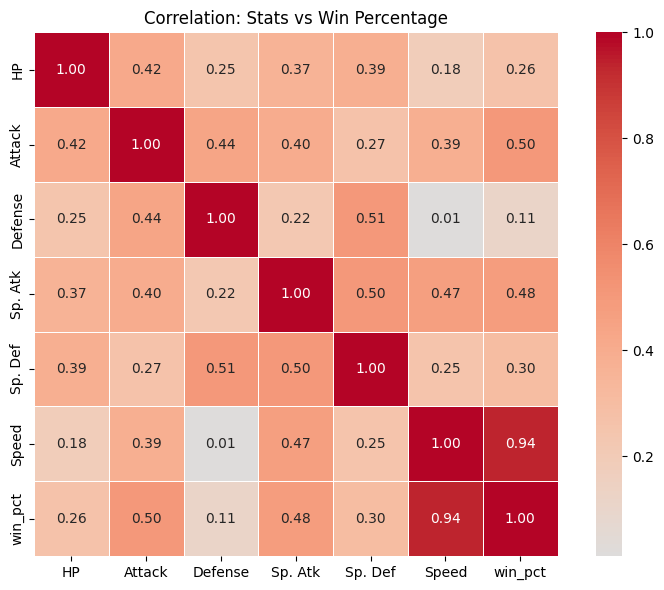

--- Correlation with win_pct (sorted) ---
win_pct    1.000
Speed      0.938
Attack     0.503
Sp. Atk    0.481
Sp. Def    0.302
HP         0.262
Defense    0.115
Name: win_pct, dtype: float64


In [13]:
# STEP 2a: Correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

# The core numeric stats + win_pct
stat_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'win_pct']

corr = df[stat_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation: Stats vs Win Percentage')
plt.tight_layout()
plt.show()

# --- Print correlation with win_pct, sorted ---
print("--- Correlation with win_pct (sorted) ---")
print(corr['win_pct'].sort_values(ascending=False).round(3))

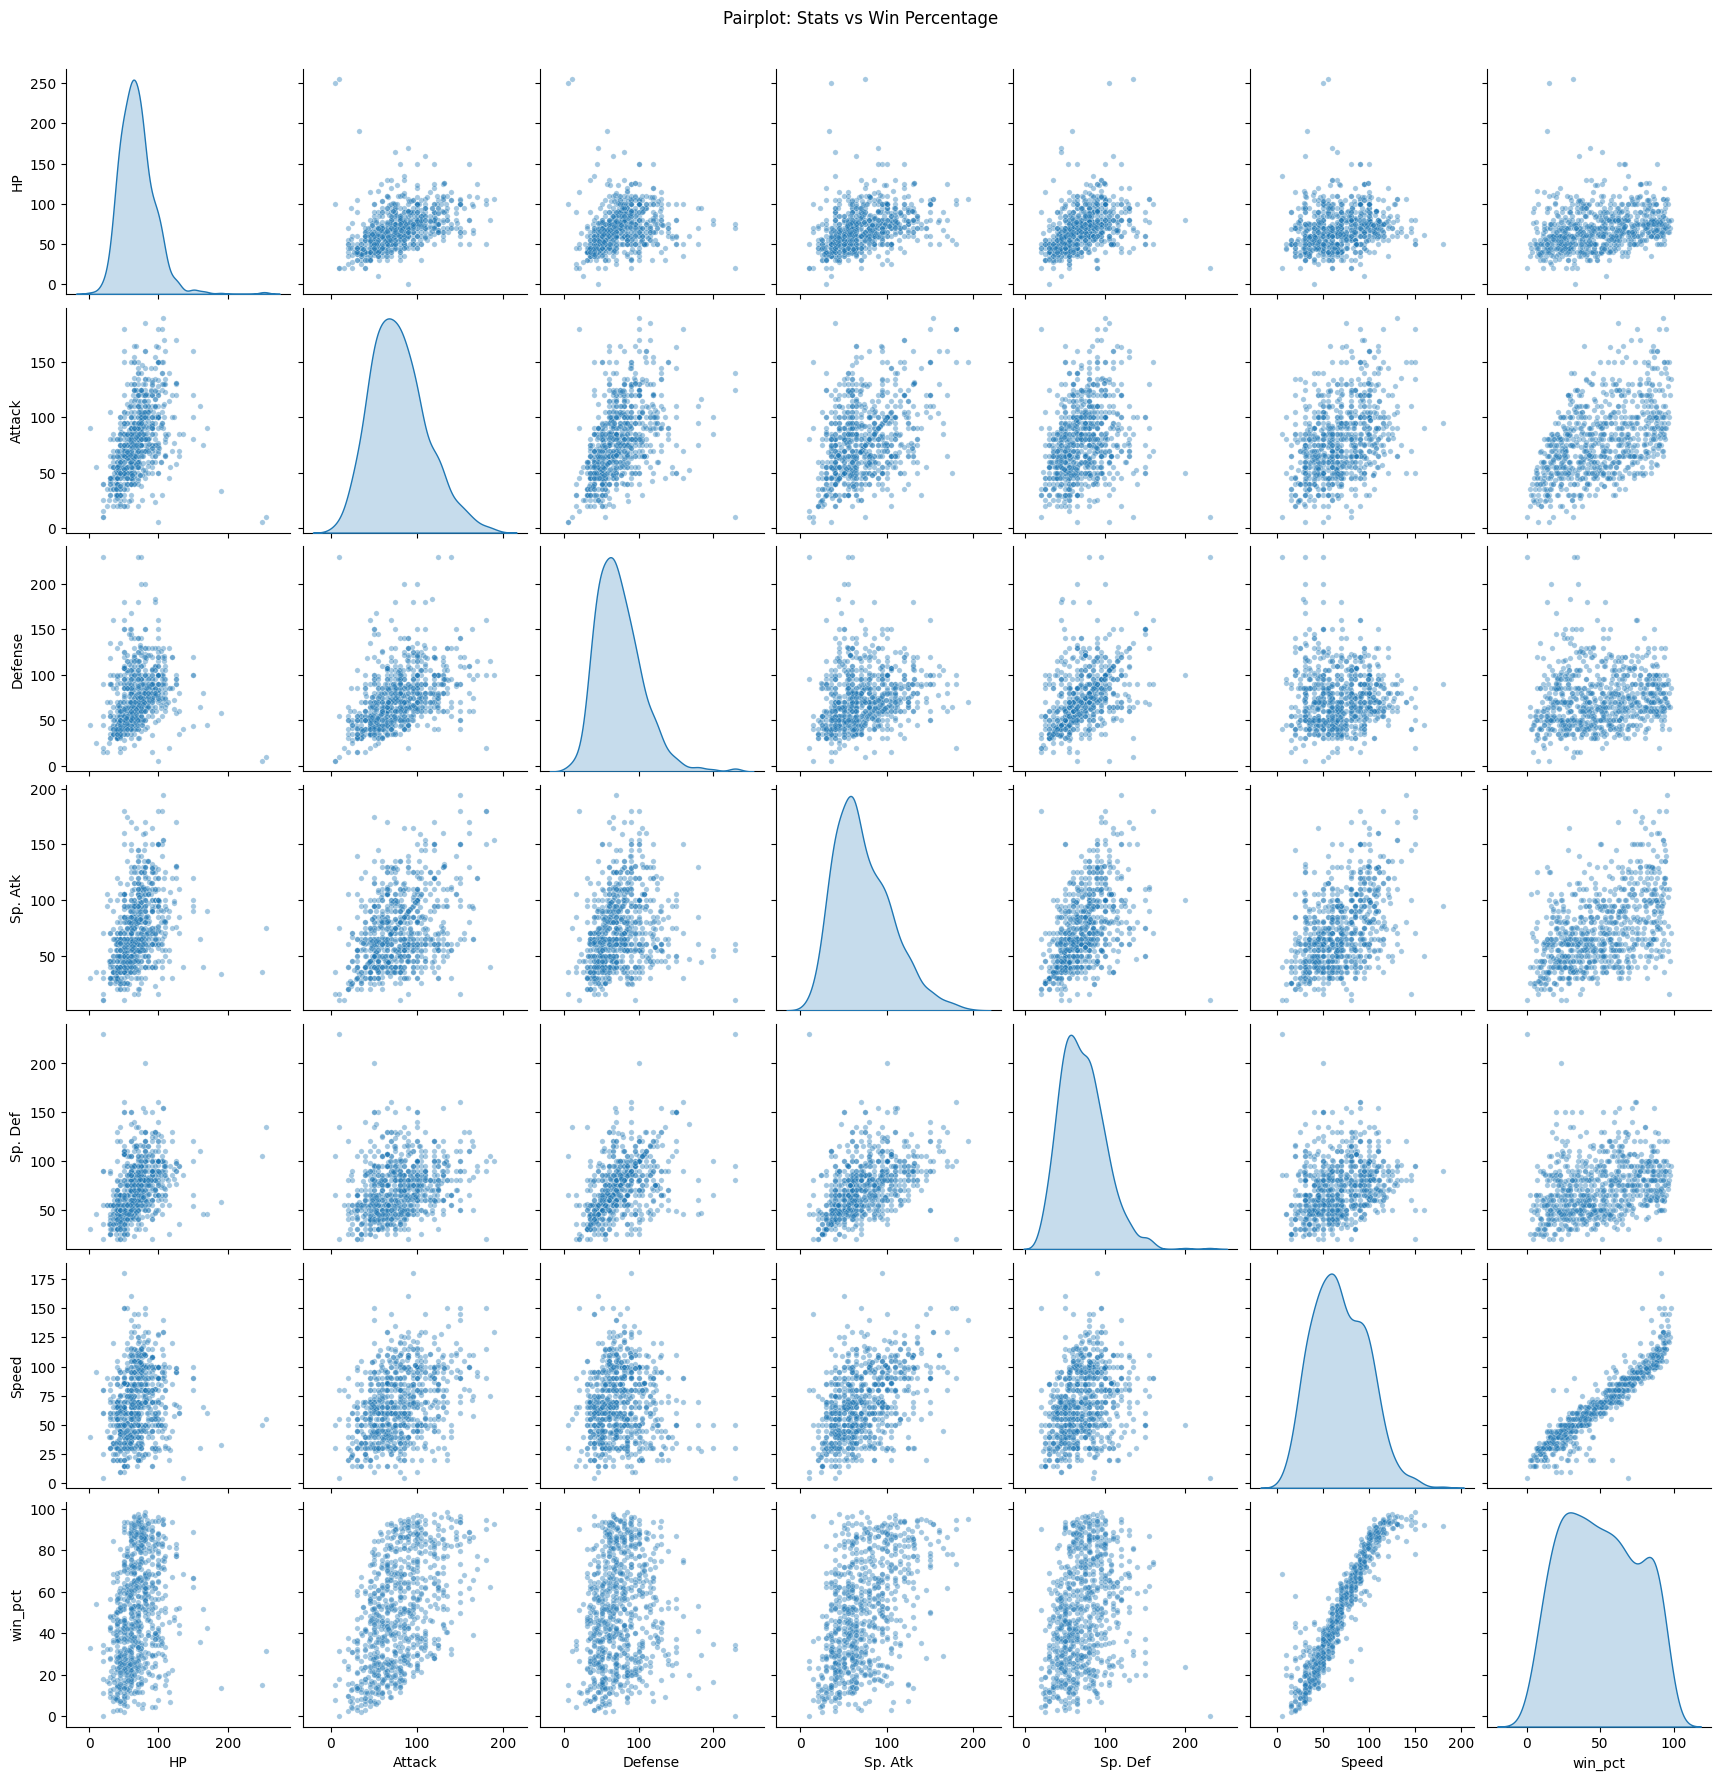

In [14]:
# STEP 2b: Pairplot of stats vs win_pct

# Pairplot of all numeric stats + win_pct.
pair_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'win_pct']

sns.pairplot(df[pair_cols], diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot: Stats vs Win Percentage', y=1.02)
plt.show()

In [15]:
# STEP 2c: Top 10 Pokemon by win percentage

top10 = df.sort_values('win_pct', ascending=False).head(10)

cols = ['Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense',
        'Sp. Atk', 'Sp. Def', 'Speed', 'total_battles', 'wins', 'win_pct']
print("--- Top 10 Pokemon by Win % ---")
print(top10[cols].to_string(index=False))

# --- Compare top-10 average stats vs overall average ---
stat_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
print("\n--- Top 10 avg stats vs ALL Pokemon avg ---")
comparison = pd.DataFrame({
    'Top 10 avg': top10[stat_cols].mean().round(1),
    'Overall avg': df[stat_cols].mean().round(1)
})
comparison['difference'] = (comparison['Top 10 avg'] - comparison['Overall avg']).round(1)
print(comparison)

--- Top 10 Pokemon by Win % ---
                    Name  Type 1   Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  total_battles  wins   win_pct
         Mega Aerodactyl    Rock   Flying  80     135       85       70       95    150          129.0 127.0 98.449612
                 Weavile    Dark      Ice  70     120       65       45       85    125          119.0 116.0 97.478992
  Tornadus Therian Forme  Flying     None  79     100       80      110       90    121          125.0 121.0 96.800000
           Mega Beedrill     Bug   Poison  65     150       40       15       80    145          119.0 115.0 96.638655
              Aerodactyl    Rock   Flying  80     105       65       60       75    130          141.0 136.0 96.453901
            Mega Lopunny  Normal Fighting  65     136       94       54       96    135          129.0 124.0 96.124031
                Greninja   Water     Dark  72      95       67      103       71    122          127.0 122.0 96.062992
Meloetta Pirouet

/tmp/ipykernel_1412/4133253632.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='win_pct', y='Name', palette='viridis')


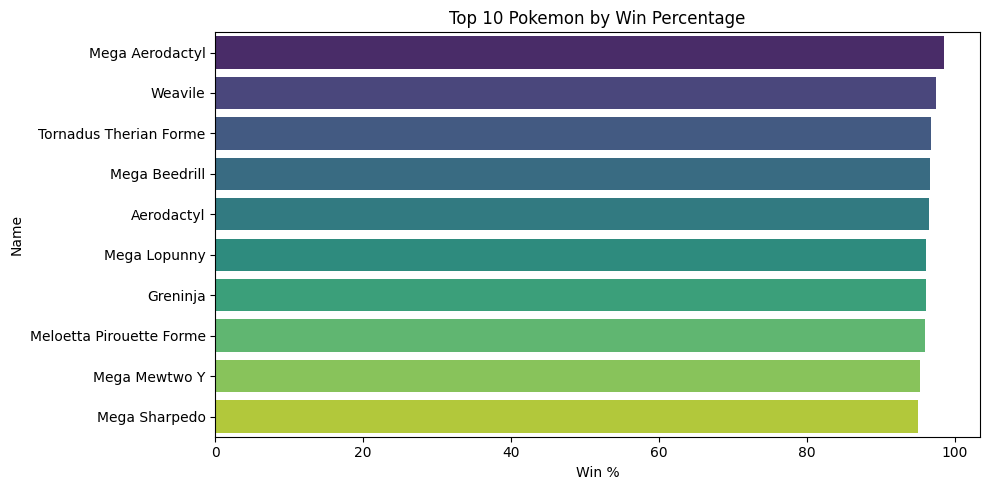

In [16]:
# --- Bar chart of the top 10 ---
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='win_pct', y='Name', palette='viridis')
plt.title('Top 10 Pokemon by Win Percentage')
plt.xlabel('Win %')
plt.tight_layout()
plt.show()

In [17]:
# STEP 3a: Prepare features & split
from sklearn.model_selection import train_test_split

# Features: the six base stats (numeric, no leakage from wins/total_battles)
feature_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X = df[feature_cols]
y = df['win_pct']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (627, 6)  Test: (157, 6)


In [18]:
# STEP 3b: Train & compare 3 regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# XGBoost is pre-installed in Colab; install only if the import fails
try:
    from xgboost import XGBRegressor
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBRegressor

# --- Define the three models ---
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
}

# --- Train, predict, evaluate ---
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2  = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae, 3), 'R2': round(r2, 3)})
    print(f"{name:20s} -> MAE: {mae:.3f}   R2: {r2:.3f}")

# --- Comparison table, sorted by MAE (lower = better) ---
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
print("\n--- Model Comparison (sorted by MAE) ---")
print(results_df.to_string(index=False))

Linear Regression    -> MAE: 6.153   R2: 0.873
Random Forest        -> MAE: 4.404   R2: 0.939
XGBoost              -> MAE: 4.550   R2: 0.940

--- Model Comparison (sorted by MAE) ---
            Model   MAE    R2
    Random Forest 4.404 0.939
          XGBoost 4.550 0.940
Linear Regression 6.153 0.873


--- Random Forest feature importance ---
Speed      92.9%
Attack      4.2%
HP          1.0%
Defense     0.7%
Sp. Atk     0.6%
Sp. Def     0.6%
dtype: object


/tmp/ipykernel_1412/173517822.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


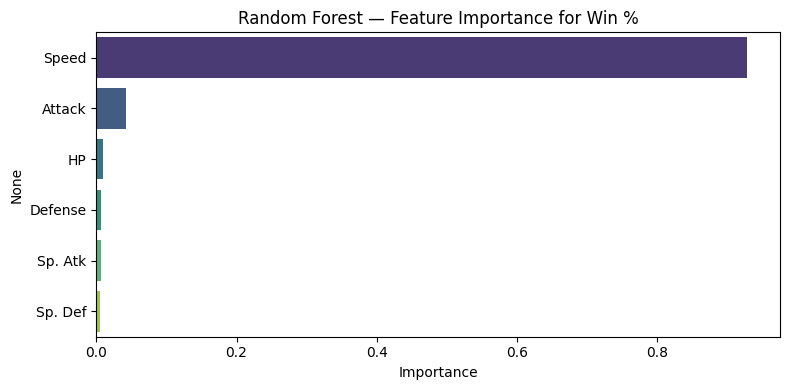

In [19]:
# STEP 3c: Feature importance + predicted vs actual

# --- Feature importance from Random Forest (best MAE) ---
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("--- Random Forest feature importance ---")
print((importances * 100).round(1).astype(str) + '%')

plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest — Feature Importance for Win %')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

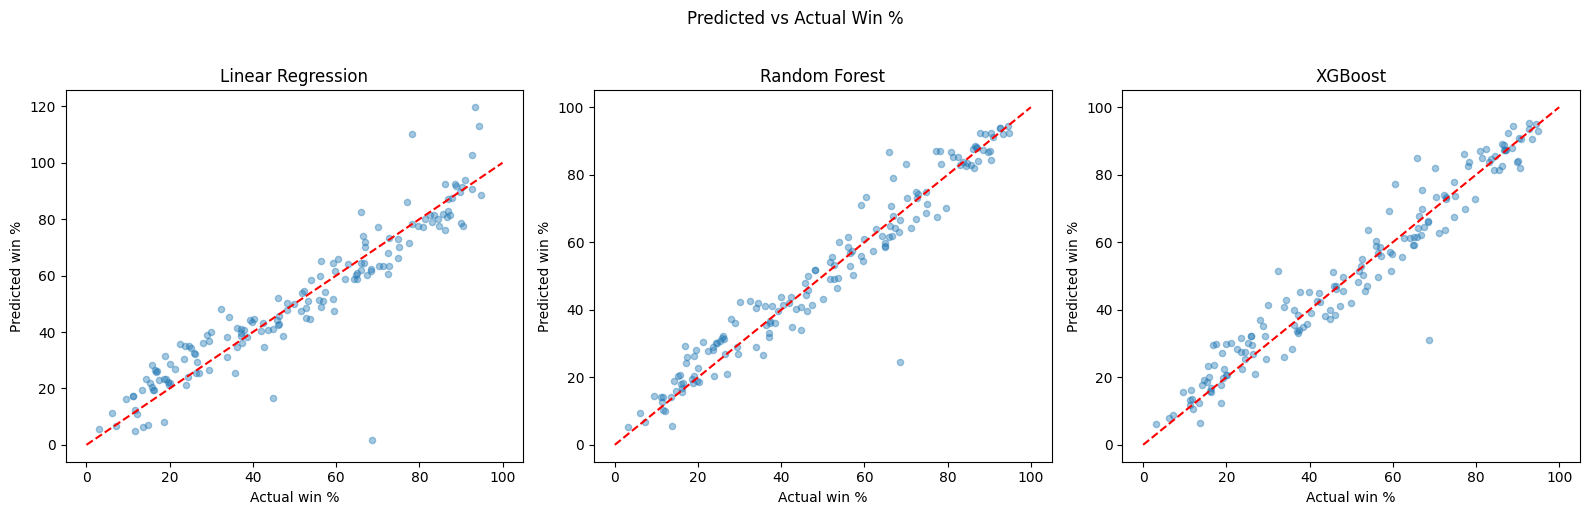

In [20]:
# --- Predicted vs Actual for all 3 models ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    ax.scatter(y_test, preds, alpha=0.4, s=20)
    ax.plot([0, 100], [0, 100], 'r--', lw=1.5)   # perfect-prediction line
    ax.set_xlabel('Actual win %')
    ax.set_ylabel('Predicted win %')
    ax.set_title(f'{name}')
plt.suptitle('Predicted vs Actual Win %', y=1.02)
plt.tight_layout()
plt.show()